# Notebook 04.1: ResNet18 — Full Fine-Tune (Auste-style)

Alternative recipe inspired by Auste's notebook, which scored AUC 0.94 / score 0.91 on val with a much simpler training loop:

- **All layers unfrozen**, single LR for everything (no freezing, no differential LR).
- **`Adam(lr=1e-4)`** over `model.parameters()` — every weight gets updated together.
- **8 epochs**, save best-val-AUROC checkpoint.
- Keeps **ImageNet normalization** and **mild augmentation** (both are lifts over Auste's bare version).

### Why full fine-tune can beat staged fine-tune here
- Small dataset (1262 train images) + big domain gap (ImageNet natural photos → chest X-rays) = early conv filters benefit from adapting, not staying frozen.
- Only 5-10 epochs → not enough to catastrophically forget ImageNet features, so the risk of full fine-tune is low.

### Expected behavior
Auste peaked at epoch 3 (AUROC 0.941, score 0.91 after threshold tuning). With our augmentation + normalization, expect similar or slightly higher, possibly peaking 1-2 epochs later.

---
## Step 1: Imports

In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

print("Imports OK")

Imports OK


/Users/jasonsmith/Desktop/medical-cv-hackathon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Reproducibility and Device

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Step 3: Configuration

Using `IMG_SIZE=224` — ResNet18's native pretraining resolution, same as Auste's notebook. Fast and fair comparison.

In [3]:
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRAIN_CSV = REPO / "data" / "train_val" / "train_val.csv"
TRAIN_IMG_DIR = REPO / "data" / "train_val" / "images"
TEST_IMG_DIR = REPO / "data" / "test_images"
PRED_DIR = REPO / "outputs" / "predictions"
CKPT_DIR = REPO / "outputs" / "checkpoints"
PRED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224          # ResNet18 native pretraining resolution
BATCH_SIZE = 16
NUM_WORKERS = 0
VAL_FRAC = 0.2
EPOCHS = 8
LR = 1e-4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"IMG_SIZE  : {IMG_SIZE}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"EPOCHS    : {EPOCHS}")
print(f"LR        : {LR}")

IMG_SIZE  : 224
BATCH_SIZE: 16
EPOCHS    : 8
LR        : 0.0001


## Step 4: Load labels and inspect class balance

In [4]:
df = pd.read_csv(TRAIN_CSV)
df = df.rename(columns={
    "Image Index": "image_file",
    "Patient Age": "age",
    "Patient Sex": "sex",
    "Finding Labels": "finding",
})
df["label"] = (df["finding"] == "Cardiomegaly").astype(int)

print(df.head())
print("\nFinding counts:")
print(df["finding"].value_counts())
print(f"\nPositive rate: {df['label'].mean():.3f}")
print(f"Total         : {len(df)}")

       image_file  age sex       finding  label
0  IMG_000838.png   65   F  Cardiomegaly      1
1  IMG_000239.png   76   F  Cardiomegaly      1
2  IMG_000217.png   61   M    No Finding      0
3  IMG_001193.png   52   F    No Finding      0
4  IMG_001097.png   35   F    No Finding      0

Finding counts:
finding
No Finding      858
Cardiomegaly    720
Name: count, dtype: int64

Positive rate: 0.456
Total         : 1578


## Step 5: Dataset class

In [5]:
class CardiomegalyDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, return_label=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.return_label = return_label

    def __len__(self):
        return len(self.df)

    def _load_image(self, fname):
        img = Image.open(self.img_dir / fname)
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row["image_file"])
        if self.transform is not None:
            img = self.transform(img)
        if not self.return_label:
            return img, row["image_file"]
        return img, torch.tensor(row["label"], dtype=torch.float32)

## Step 6: Stratified train / validation split

80/20, stratified on the label. `SEED=42` matches every other notebook, so the same images end up in train vs. val across 01, 02, 03, 04.

In [6]:
train_df, val_df = train_test_split(
    df, test_size=VAL_FRAC, stratify=df["label"], random_state=SEED
)
print(f"Train: {len(train_df)}  (pos rate {train_df['label'].mean():.3f})")
print(f"Val  : {len(val_df)}  (pos rate {val_df['label'].mean():.3f})")

Train: 1262  (pos rate 0.456)
Val  : 316  (pos rate 0.456)


## Step 7: Transforms

In [7]:
def build_transform(img_size, augment=False):
    ops = []
    if img_size is not None:
        ops.append(T.Resize((img_size, img_size)))
    if augment:
        ops += [
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=5),
            T.ColorJitter(brightness=0.1, contrast=0.1),
        ]
    ops += [T.ToTensor(), T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)]
    return T.Compose(ops)

# Training uses augmentation; val uses clean resize only.
train_tf = build_transform(IMG_SIZE, augment=True)
val_tf = build_transform(IMG_SIZE, augment=False)

train_ds = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=train_tf)
val_ds = CardiomegalyDataset(val_df, TRAIN_IMG_DIR, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

Train batches: 79
Val   batches: 20


---
## Metrics helpers

In [8]:
def sens_spec(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    pred = (y_prob >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return sens, spec

def datathon_score(auroc, sens, spec):
    return 0.5 * auroc + 0.25 * sens + 0.25 * spec

def best_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    return float(thr[np.argmax(tpr - fpr)])

## Train / Eval loops

In [9]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, ps = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs).squeeze(1)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        ys.extend(labels.numpy().tolist())
        ps.extend(probs.tolist())
    ys = np.array(ys); ps = np.array(ps)
    auroc = roc_auc_score(ys, ps)
    sens, spec = sens_spec(ys, ps, threshold=0.5)
    return {"auroc": auroc, "sens": sens, "spec": spec, "y": ys, "p": ps}

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    pbar = tqdm(loader, leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device); labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total += loss.item()
        pbar.set_description(f"loss {loss.item():.3f}")
    return total / len(loader)

def train(model, train_loader, val_loader, optimizer, epochs, device, tag="model"):
    criterion = nn.BCEWithLogitsLoss()
    best = {"auroc": -1.0, "state": None, "epoch": 0}
    history = []
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val = evaluate(model, val_loader, device)
        dt = time.time() - t0
        score = datathon_score(val["auroc"], val["sens"], val["spec"])
        history.append({"epoch": epoch, "loss": tr_loss, **{k: val[k] for k in ("auroc", "sens", "spec")}, "score": score})
        star = ""
        if val["auroc"] > best["auroc"]:
            best = {"auroc": val["auroc"], "state": copy.deepcopy(model.state_dict()), "epoch": epoch}
            star = " ★"
            torch.save(model.state_dict(), CKPT_DIR / f"{tag}_best.pt")
        print(
            f"[{tag}] ep {epoch:02d}/{epochs}  loss {tr_loss:.4f}  "
            f"AUROC {val['auroc']:.4f}  sens {val['sens']:.3f}  spec {val['spec']:.3f}  "
            f"score {score:.4f}  ({dt:.1f}s){star}"
        )
    model.load_state_dict(best["state"])
    return model, history, best

---
## Train: Full fine-tune

Replace `model.fc` with a single `Linear(512, 1)` (bare, no Dropout — matches Auste's recipe). Unfreeze **all** parameters and train with `Adam(lr=1e-4)`.

In [10]:
def build_full_finetune():
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    # All params remain trainable (no freezing).
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

model = build_full_finetune().to(device)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.2f}%)")

optimizer = optim.Adam(model.parameters(), lr=LR)
model, history, best = train(
    model, train_loader, val_loader, optimizer, epochs=EPOCHS, device=device, tag="resnet18_fullft"
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/jasonsmith/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 44.7MB/s]


Trainable: 11,177,025 / 11,177,025 (100.00%)


[resnet18_fullft] ep 01/8  loss 0.5579  AUROC 0.8949  sens 0.938  spec 0.663  score 0.8475  (34.4s) ★


[resnet18_fullft] ep 02/8  loss 0.3963  AUROC 0.8944  sens 0.660  spec 0.878  score 0.8316  (29.1s)


...

[resnet18_fullft] ep 04/8  loss 0.2740  AUROC 0.9163  sens 0.806  spec 0.855  score 0.8732  (27.9s)


[resnet18_fullft] ep 05/8  loss 0.2810  AUROC 0.9430  sens 0.833  spec 0.895  score 0.9037  (28.3s) ★


[resnet18_fullft] ep 06/8  loss 0.2107  AUROC 0.9559  sens 0.903  spec 0.907  score 0.9304  (30.3s) ★


[resnet18_fullft] ep 07/8  loss 0.1699  AUROC 0.9344  sens 0.965  spec 0.709  score 0.8858  (28.0s)


[resnet18_fullft] ep 08/8  loss 0.1673  AUROC 0.9324  sens 0.938  spec 0.773  score 0.8939  (28.3s)


---
## Validation ROC + threshold tuning

Single model now (not 3 stages), so we directly evaluate it, plot the ROC, and pick a threshold.

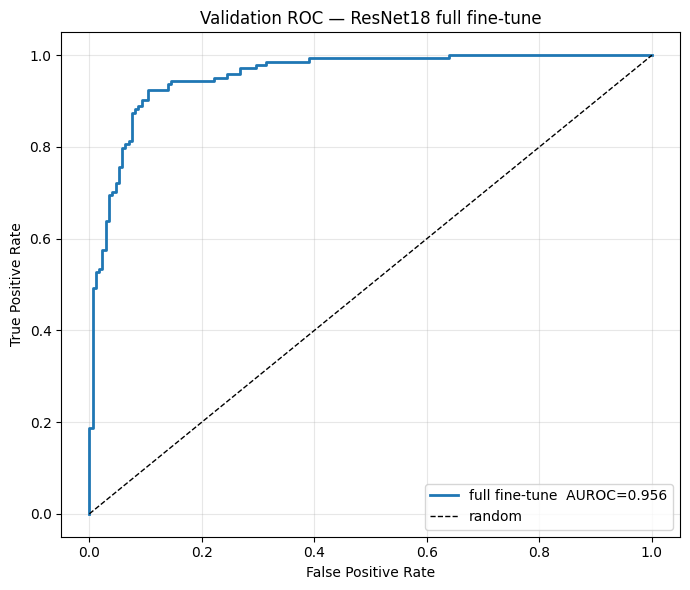

In [11]:
val = evaluate(model, val_loader, device)
fpr, tpr, _ = roc_curve(val["y"], val["p"])

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, lw=2, label=f"full fine-tune  AUROC={val['auroc']:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Validation ROC — ResNet18 full fine-tune")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## Best threshold + final score

Grid-search threshold 0.1 → 0.9 in 0.05 steps, pick the one maximizing the datathon score (same approach Auste used — for datathon scoring this is equivalent to Youden's J but directly interpretable).

In [12]:
thresholds = np.arange(0.1, 0.91, 0.05)
rows = []
for t in thresholds:
    s, sp = sens_spec(val["y"], val["p"], threshold=t)
    rows.append({"threshold": t, "auc": val["auroc"], "sens": s, "spec": sp,
                 "score": datathon_score(val["auroc"], s, sp)})
results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

best_row = results_df.loc[results_df["score"].idxmax()]
best_thr = float(best_row["threshold"])
best_score = float(best_row["score"])
print(f"\nBest threshold: {best_thr:.2f}  score: {best_score:.4f}")

 threshold      auc     sens     spec    score
      0.10 0.955911 0.965278 0.732558 0.902414
      0.15 0.955911 0.944444 0.790698 0.911741
      0.20 0.955911 0.944444 0.808140 0.916101
      0.25 0.955911 0.944444 0.837209 0.923369
      0.30 0.955911 0.930556 0.860465 0.925711
      0.35 0.955911 0.923611 0.860465 0.923974
      0.40 0.955911 0.923611 0.877907 0.928335
      0.45 0.955911 0.909722 0.895349 0.929223
      0.50 0.955911 0.902778 0.906977 0.930394
      0.55 0.955911 0.881944 0.918605 0.928093
      0.60 0.955911 0.840278 0.924419 0.919130
      0.65 0.955911 0.798611 0.936047 0.911620
      0.70 0.955911 0.763889 0.941860 0.904393
      0.75 0.955911 0.708333 0.953488 0.893411
      0.80 0.955911 0.673611 0.965116 0.887637
      0.85 0.955911 0.618056 0.970930 0.875202
      0.90 0.955911 0.548611 0.976744 0.859294

Best threshold: 0.50  score: 0.9304


---
## Generate submission CSV for the 176 test images

In [13]:
test_files = sorted(p.name for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() == ".png")
print(f"Test images: {len(test_files)}")

test_df = pd.DataFrame({"image_file": test_files, "label": 0})
test_tf = build_transform(IMG_SIZE, augment=False)
test_ds = CardiomegalyDataset(test_df, TEST_IMG_DIR, transform=test_tf, return_label=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model.eval()
all_probs, all_names = [], []
with torch.no_grad():
    for imgs, names in tqdm(test_loader, desc="test inference"):
        imgs = imgs.to(device)
        logits = model(imgs).squeeze(1)
        logits_flip = model(torch.flip(imgs, dims=[3])).squeeze(1)
        probs = (torch.sigmoid(logits) + torch.sigmoid(logits_flip)) / 2
        all_probs.extend(probs.cpu().numpy().tolist())
        all_names.extend(names)

sub = pd.DataFrame({"image_file": all_names, "prob": all_probs})
sub["pred"] = (sub["prob"] >= best_thr).astype(int)
sub = sub.sort_values("image_file").reset_index(drop=True)

stamp = time.strftime("%Y%m%d_%H%M")
out_path = PRED_DIR / f"submission_resnet18_fullft_{stamp}.csv"
sub.to_csv(out_path, index=False)
print(f"\nWrote {out_path}")
print(sub.head())
print(f"\nPositive rate in submission: {sub['pred'].mean():.3f}")

Test images: 176


test inference: 100%|██████████| 11/11 [00:02<00:00,  3.99it/s]


Wrote /Users/jasonsmith/Desktop/medical-cv-hackathon/outputs/predictions/submission_resnet18_fullft_20260420_2101.csv
       image_file      prob  pred
0  IMG_000018.png  0.483875     0
1  IMG_000021.png  0.000755     0
2  IMG_000039.png  0.160267     0
3  IMG_000044.png  0.042169     0
4  IMG_000047.png  0.361145     0

Positive rate in submission: 0.330
